In [1]:
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv, find_dotenv
from os import environ
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import (
    MetaData, Table, Column, Integer, String,
    DateTime, Float, UniqueConstraint
)
from sqlalchemy.engine.base import Engine

# Подключение к БД

In [2]:
load_dotenv(find_dotenv())

True

In [3]:
DB_USER = environ['DB_USER']
DB_HOST = environ['DB_HOST']
DB_PORT = environ['DB_PORT']
DB_NAME = environ['DB_NAME']
DB_PASSWORD = environ['DB_PASSWORD']

In [4]:
db_conn_url = f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"

In [5]:
conn = create_engine(db_conn_url)

# Сбор данных

In [6]:
def extract(conn: Engine):
    sql = """
        select
            b.id as building_id,
            b.build_year,
            b.building_type_int,
            b.latitude,
            b.longitude,
            b.ceiling_height,
            b.flats_count,
            b.floors_total,
            b.has_elevator,
            f.id as flat_id,
            f.floor,
            f.kitchen_area,
            f.living_area,
            f.rooms,
            f.is_apartment,
            f.studio,
            f.total_area,
            f.price
        from buildings as b
        left join flats as f on b.id = f.building_id
    """
    data = pd.read_sql(sql, conn)
    return data

In [7]:
db_data = extract(conn)

In [8]:
db_data

,building_id,build_year,building_type_int,latitude,longitude,ceiling_height,flats_count,floors_total,has_elevator,flat_id,floor,kitchen_area,living_area,rooms,is_apartment,studio,total_area,price
0,6220,1965,6,55.717113,37.781120,2.64,84,12,True,0,9,9.90,19.900000,1,False,False,35.099998,9500000
1,18012,2001,2,55.794849,37.608013,3.00,97,10,True,1,7,0.00,16.600000,1,False,False,43.000000,13500000
2,17821,2000,4,55.740040,37.761742,2.70,80,10,True,2,9,9.00,32.000000,2,False,False,56.000000,13500000
3,18579,2002,4,55.672016,37.570877,2.64,771,17,True,3,1,10.10,43.099998,3,False,False,76.000000,20000000
4,9293,1971,1,55.808807,37.707306,2.60,208,9,True,4,3,3.00,14.000000,1,False,False,24.000000,5200000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141357,22455,2013,4,55.626579,37.313503,2.64,672,25,True,141357,16,11.00,18.000000,1,False,False,42.000000,10500000
141358,3162,1960,1,55.727470,37.768677,2.48,80,5,False,141358,5,5.28,28.330000,2,False,False,41.110001,7400000
141359,6513,1966,4,55.704315,37.506584,2.64,72,9,True,141359,7,5.30,20.000000,1,False,False,31.500000,9700000
141360,23952,2017,4,55.699863,37.939564,2.70,480,25,True,141360,15,13.80,33.700001,2,False,False,65.300003,11750000


# Анализ данных

In [9]:
db_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141362 entries, 0 to 141361
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   building_id        141362 non-null  int64  
 1   build_year         141362 non-null  int64  
 2   building_type_int  141362 non-null  int64  
 3   latitude           141362 non-null  float64
 4   longitude          141362 non-null  float64
 5   ceiling_height     141362 non-null  float64
 6   flats_count        141362 non-null  int64  
 7   floors_total       141362 non-null  int64  
 8   has_elevator       141362 non-null  bool   
 9   flat_id            141362 non-null  int64  
 10  floor              141362 non-null  int64  
 11  kitchen_area       141362 non-null  float64
 12  living_area        141362 non-null  float64
 13  rooms              141362 non-null  int64  
 14  is_apartment       141362 non-null  bool   
 15  studio             141362 non-null  bool   
 16  to

Пропусков нет

## Дубликаты

Полные дубликаты:

In [10]:
db_data.duplicated(keep=False).sum()

0

Квартиры-дубликаты внутри одного дома:

In [11]:
dup_mask = db_data.duplicated(subset=['building_id', 'flat_id'], keep=False)
dup_mask.sum()

0

**Вывод**: дубликатов нет

## Битые записи

In [12]:
db_data.describe()

,building_id,build_year,building_type_int,latitude,longitude,ceiling_height,flats_count,floors_total,flat_id,floor,kitchen_area,living_area,rooms,total_area,price
count,141362.000000,141362.000000,141362.000000,141362.000000,141362.000000,141362.000000,141362.000000,141362.000000,141362.000000,141362.000000,141362.000000,141362.000000,141362.000000,141362.000000,1.413620e+05
mean,14053.665235,1986.600048,3.232941,55.730059,37.589235,2.753650,251.993230,14.107554,70680.500000,7.467346,9.001579,31.056948,2.129476,62.374644,1.944162e+07
std,6988.831066,22.136409,1.459461,0.102611,0.150122,0.223275,207.336169,6.898045,40807.838714,5.717144,5.264076,23.968640,0.994340,40.295864,6.626954e+07
min,1.000000,1901.000000,0.000000,55.211460,36.864372,2.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,11.000000,1.100000e+01
25%,8535.250000,1969.000000,2.000000,55.653858,37.491764,2.640000,111.000000,9.000000,35340.250000,3.000000,6.100000,19.000000,1.000000,39.299999,8.900000e+06
50%,14332.000000,1985.000000,4.000000,55.724686,37.581146,2.640000,200.000000,14.000000,70680.500000,6.000000,8.800000,29.400000,2.000000,53.000000,1.185000e+07
75%,20475.000000,2007.000000,4.000000,55.807323,37.691055,2.800000,324.000000,17.000000,106020.750000,10.000000,10.200000,41.400002,3.000000,72.000000,1.695000e+07
max,24620.000000,2023.000000,6.000000,56.011032,37.946411,27.000000,4455.000000,99.000000,141361.000000,56.000000,203.000000,700.000000,20.000000,960.299988,9.873738e+09


В датасете есть квартиры с жилой площадью 0 кв.м. и площадью кухни 0 кв.м. - ошибка ввода.

Площадь 203 кв. м. слишком большая для кухни жилого помещения, что указывает на факт ошибки при вводе данных.

Также встречаются лоты с высотой потолка 27 м, что явно указывает на ошибку записи.

**Квартиры, жилая площадь которых больше общей площади:**

In [13]:
db_data[db_data['living_area'] > db_data['total_area']]

,building_id,build_year,building_type_int,latitude,longitude,ceiling_height,flats_count,floors_total,has_elevator,flat_id,floor,kitchen_area,living_area,rooms,is_apartment,studio,total_area,price


Таких квартир нет

**Квартиры, площадь кухни которых больше общей площади:**

In [14]:
db_data[db_data['kitchen_area'] > db_data['total_area']]

,building_id,build_year,building_type_int,latitude,longitude,ceiling_height,flats_count,floors_total,has_elevator,flat_id,floor,kitchen_area,living_area,rooms,is_apartment,studio,total_area,price
114197,12114,1977,4,55.852379,37.446415,2.64,192,9,True,114197,4,65.0,43.0,3,False,False,59.0,7800000
114453,10232,1972,6,55.851913,37.681019,2.64,95,14,True,114453,14,102.0,20.0,1,False,False,39.0,5900000


Найдено 2 квартиры - вероятно, некорректно посчитана общая площадь.

**Квартиры, у которых сумма жилой площади и кухни больше общей площади:**

In [15]:
db_data[(db_data['kitchen_area'] + db_data['living_area']) > db_data['total_area']]

,building_id,build_year,building_type_int,latitude,longitude,ceiling_height,flats_count,floors_total,has_elevator,flat_id,floor,kitchen_area,living_area,rooms,is_apartment,studio,total_area,price
498,4645,1962,6,55.806068,37.581371,2.64,64,9,True,498,5,19.5,19.500000,1,False,False,32.000000,8050000
572,23441,2016,3,55.569942,37.487621,3.00,297,16,True,572,2,21.0,65.000000,3,False,False,72.900002,17800000
1152,687,1933,1,55.778713,37.665310,4.00,161,8,True,1152,4,6.0,66.000000,3,False,False,67.000000,35000000
1631,22656,2014,2,55.642139,37.604446,3.00,213,20,False,1631,7,12.0,53.200001,3,False,False,65.199997,16990000
1651,7101,1967,4,55.706722,37.674015,2.70,251,9,True,1651,9,7.7,25.400000,1,False,False,33.099998,20000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
138072,23170,2015,4,55.602734,37.367435,2.74,462,17,True,138072,11,13.0,58.400002,2,False,False,62.000000,16300000
138545,21823,2011,2,55.677540,37.634399,3.00,869,33,True,138545,8,40.0,80.000000,3,False,False,103.800000,30749912
138570,23433,2016,3,55.468174,37.289444,3.00,123,6,True,138570,4,17.0,46.200001,1,False,False,55.930000,12899990
139880,2110,1958,1,55.680698,37.563538,3.00,69,5,False,139880,4,32.0,51.400002,3,False,False,77.500000,15600000


Найдено 152 квартиры - вероятно, некорректно почитала общая площадь

**Квартиры, которые находятся выше последнего этажа:**

In [16]:
db_data[db_data['floor'] > db_data['floors_total']]

,building_id,build_year,building_type_int,latitude,longitude,ceiling_height,flats_count,floors_total,has_elevator,flat_id,floor,kitchen_area,living_area,rooms,is_apartment,studio,total_area,price


Таких записей нет

**Вывод:** всего 154 битые записи из 141362, что составляет меньше 1% от всего датасета.

Удалим записи, т.к. их мало, а при попытке восстановлении записей есть шанс восстановить их с ошибками.

## Выбросы

In [17]:
log_features = {'price', 'total_area', 'living_area', 'kitchen_area', 'ceiling_height', 'rooms', 'floor', 'floors_total'}

In [18]:
def boxplot(data: pd.Series, feat_name: str):
    fig, axes = plt.subplots(figsize=(4, 6))
    bp = axes.boxplot(
        data,
        vert=True,
        patch_artist=True,
        widths=0.5,
        showfliers=True,
        flierprops=dict(
            marker='o', markersize=3,
            markerfacecolor='crimson', markeredgecolor='crimson',
            alpha=0.4
        ),
        boxprops=dict(facecolor='steelblue', alpha=0.6, edgecolor='black'),
        medianprops=dict(color='darkred', linewidth=2),
        whiskerprops=dict(color='black'),
        capprops=dict(color='black'),
    )
    axes.set_yscale('log')
    plt.suptitle(f'{feat_name} (log-scale) — визуализация выбросов', fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

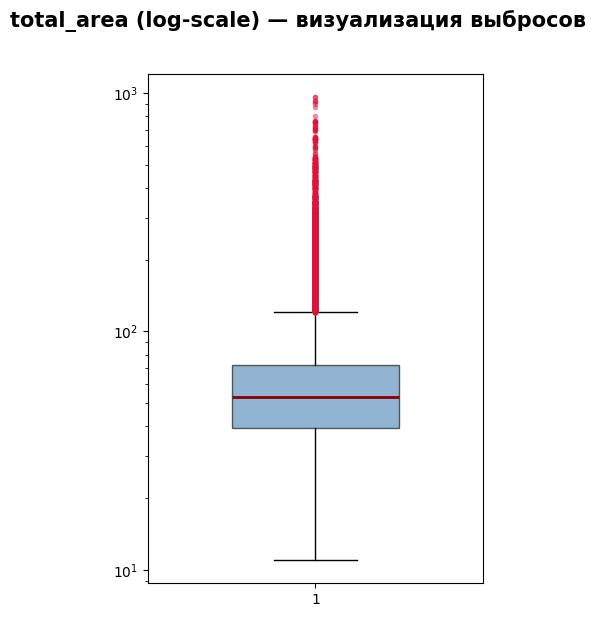

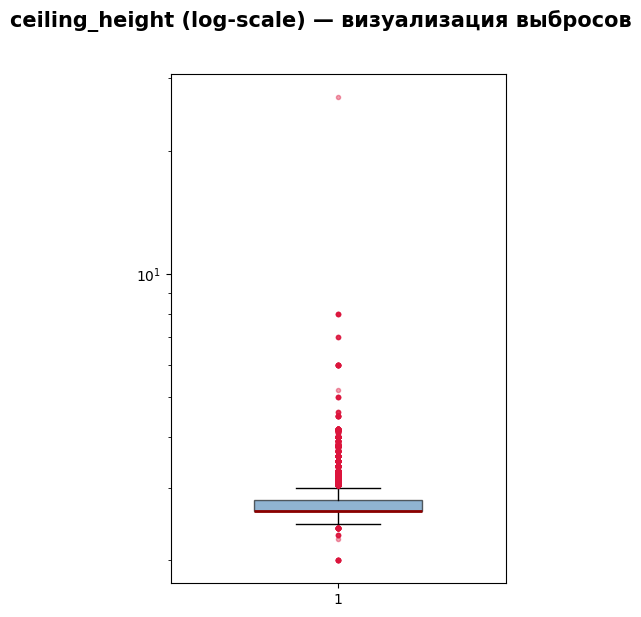

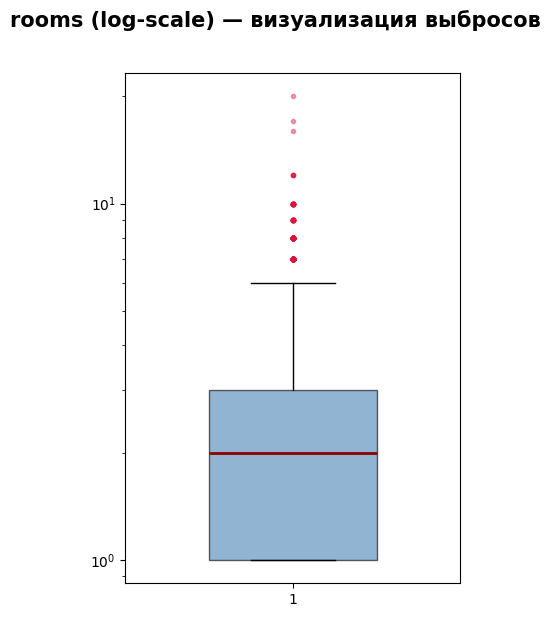

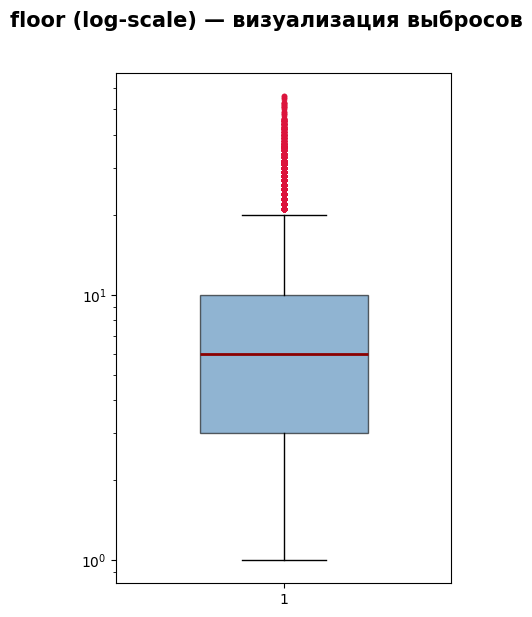

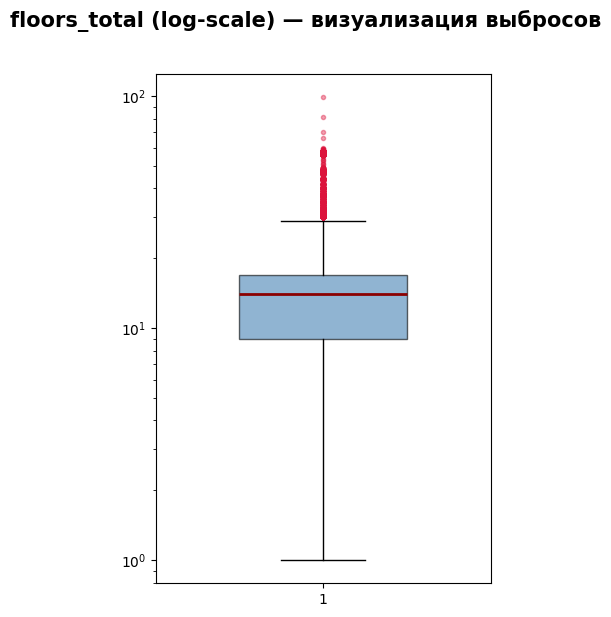

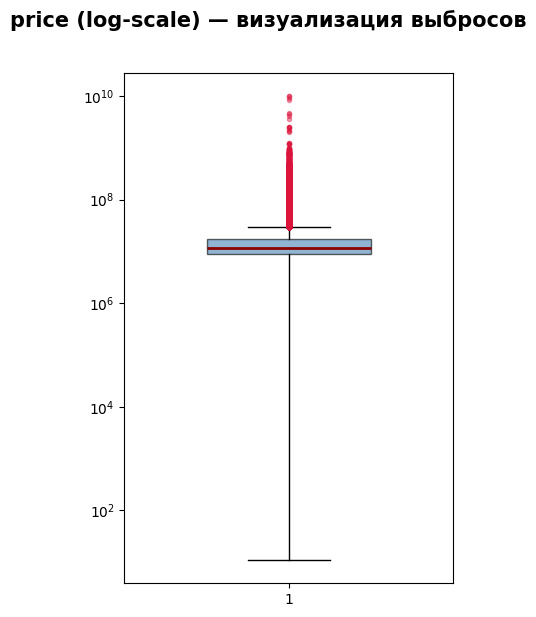

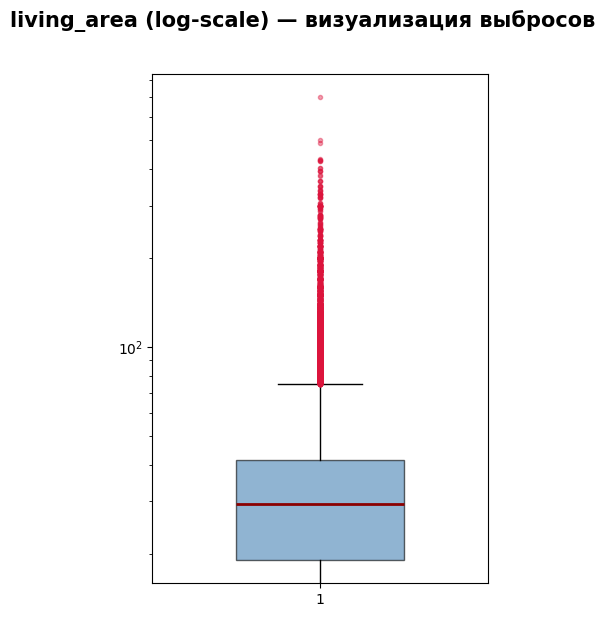

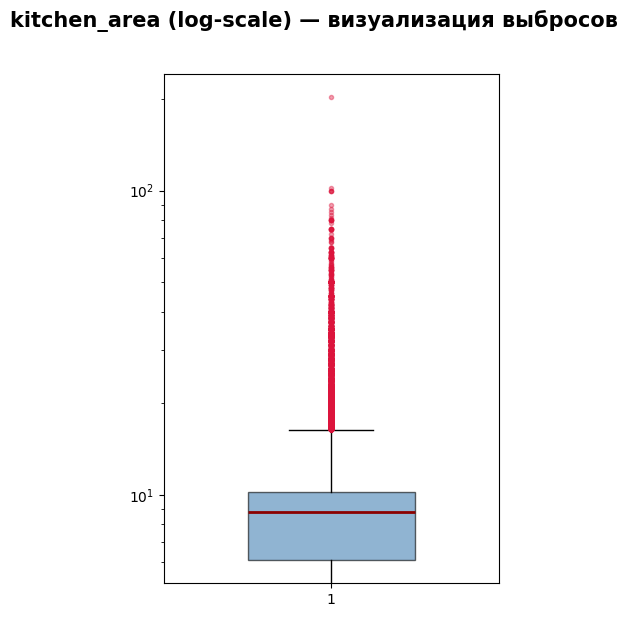

In [19]:
for feat in log_features:
    data = db_data[feat].dropna()
    boxplot(data, feat)

**Top whisker**

In [20]:
def calculate_top_whisker(df: pd.DataFrame, column: str, k: float = 1.5) -> float:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    
    return q1 - k * iqr, q3 + k * iqr

In [21]:
for feat in log_features:
    iqr = calculate_top_whisker(db_data, feat)
    print(f"{feat}: {iqr}")

total_area: (-9.750001907348633, 121.05000114440918)
ceiling_height: (2.4000003337860107, 3.0399997234344482)
rooms: (-2.0, 6.0)
floor: (-7.5, 20.5)
floors_total: (-3.0, 29.0)
price: (-3175000.0, 29025000.0)
living_area: (-14.60000228881836, 75.00000381469727)
kitchen_area: (-0.04999995231628418, 16.34999966621399)


**Итог**

Общая площадь: объекты с общей площадью > 121 кв. м. считаем выбросами - возможно, встречается элитная недвижимость и нежелые лоты.

Площадь кухни: объекты с площадью кухни более 16.5 кв. м. будем считать выбросами. Так же сложно представить кухни менее 4 кв. м.

Жилая площадь: объекты с жилой площадью более 75 кв. м. являются выбросами - слишком большая площадь для типовой жилой застройки. Кроме лоты с жилой площадью менее 8 кв.м. слишком малы даже для студий.

Стоимость: все объекты с ценой выше 29 млн статистически являются выбросами: аналогично с жилой площадью - может встречаться элитная или коммерческая недвижимость.

Высота потолков: объекты с высотой потолка меньше 2.4 м. и больше 3.03 являются выбросами: в датасете встречаются разные виды недвижимости.

Количество комнат: объекты с более чем 6 комнатами будем считать выбросами: это либо элитная, либо коммерческая недвижимость.

Этаж: лоты, расположенные выше 20 этажа являются выбросами: скорее всего, это недвижимость в небоскребах (например, Москва Сити).

Общее количество этажей: лоты, расположенный в зданиях выше 29 этажей являются выбросами (аналогично с признаком "этаж").

Также удалим из датасета лоты, у которых общая площадь меньше жилой площади кухни или ее суммы с жилой площадью.

# Обработка данных

In [22]:
def transform(data: pd.DataFrame):
    # удаление объектов, общая площадь которых меньше площади кухни:
    filtered_data = data.drop(data[data['kitchen_area'] > data['total_area']].index)
    # удаление объектов, общая площадь которых меньше суммы жилой площади и площади кухни:
    filtered_data.drop(
        filtered_data[(filtered_data['kitchen_area'] + filtered_data['living_area']) > filtered_data['total_area']].index, 
        inplace=True
    )
    # удаление выбросов по площади кухни:
    filtered_data.drop(
        filtered_data[(filtered_data['kitchen_area'] < 4) | (filtered_data['kitchen_area'] > 16.5)].index, 
        inplace=True
    )
    # удаление выбросов по жилой площади:
    filtered_data.drop(
        filtered_data[(filtered_data['living_area'] < 8) | (filtered_data['living_area'] > 75)].index, 
        inplace=True
    )
    # удаление выбросов по общей площади:
    filtered_data.drop(filtered_data[filtered_data['total_area'] > 121].index, inplace=True)
    # удаление выбросов по высоте потолков:
    filtered_data.drop(
        filtered_data[(filtered_data['ceiling_height'] < 2.4) | (filtered_data['ceiling_height'] > 3.03)].index, 
        inplace=True
    )
    # удаление выбросов по количеству комнат:
    filtered_data.drop(filtered_data[filtered_data['rooms'] > 6].index, inplace=True)
    # удаление выбросов по номеру этажа:
    filtered_data.drop(filtered_data[filtered_data['floor'] > 20].index, inplace=True)
    # удаление выбросов по количеству этажей в здании:
    filtered_data.drop(filtered_data[filtered_data['floors_total'] > 29].index, inplace=True)
    # удаление выбросов по стоимости:
    filtered_data.drop(filtered_data[filtered_data['price'] > 29025000].index, inplace=True)
    return filtered_data

In [23]:
transformed_data = transform(db_data)

In [24]:
transformed_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 101073 entries, 0 to 141361
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   building_id        101073 non-null  int64  
 1   build_year         101073 non-null  int64  
 2   building_type_int  101073 non-null  int64  
 3   latitude           101073 non-null  float64
 4   longitude          101073 non-null  float64
 5   ceiling_height     101073 non-null  float64
 6   flats_count        101073 non-null  int64  
 7   floors_total       101073 non-null  int64  
 8   has_elevator       101073 non-null  bool   
 9   flat_id            101073 non-null  int64  
 10  floor              101073 non-null  int64  
 11  kitchen_area       101073 non-null  float64
 12  living_area        101073 non-null  float64
 13  rooms              101073 non-null  int64  
 14  is_apartment       101073 non-null  bool   
 15  studio             101073 non-null  bool   
 16  total_a

# Сохранение данных

In [25]:
def create_table(conn: Engine):
    metadata = MetaData()
    Table(
        'buildings_flats',
        metadata,
        Column('building_id', Integer, primary_key=True),
        Column('build_year', Integer),
        Column('building_type_int', Integer),
        Column('latitude', Float),
        Column('longitude', Float),
        Column('ceiling_height', Float),
        Column('flats_count', Integer),
        Column('floors_total', Integer),
        Column('has_elevator', String),
        Column('flat_id', Integer),
        Column('floor', Integer),
        Column('kitchen_area', Float),
        Column('living_area', Float),
        Column('rooms', Integer),
        Column('is_apartment', String),
        Column('studio', String),
        Column('total_area', Float),
        Column('price', Float),
    )
    metadata.create_all(conn)

In [26]:
create_table(conn)

In [27]:
def load(data: pd.DataFrame, db_conn: Engine, table_name: str = 'dataset'):
    data.to_sql(
        name=table_name,
        con=db_conn,
        if_exists='replace',
        index=False
    )

In [28]:
load(transformed_data, conn)